# **Avaliação de modelos de Machine Learning na identificação de ataques em Veículos Aéreos Não Tripulados**
---
## **1. Contexto**
Esse notebook é uma expansão do meu projeto anterior de estudo do uso de modelos de Machine Learning para detecção e classificação de ataques de _spoofing de GPS_ em **sistemas de Veículos Aéreos Não Tripulados (VANTs).** O dataset utilizado é retirado do artigo dos autores **Gustavo Gualberto Rocha de Lemos e Rodrigo Augusto Cardoso da Silva**, e inclui dados extraídos de sinais de GPS _autênticos_ coletados usando um **receptor de GPS de 8 canais**. Ele apresenta **13 features** extraídas em cada um dos oito canais paralelos. Em adição, três tipos de ataques de spoofing foram simulados: **simplista, intermediário e sofisticado**, além de ataques de jamming. É muito parecido com o dataset que eu já usei, porém com a adição dos ataques de jamming.

### **1.1. Descrição das features**
| Feature | O que representa |
| --- | --- |
| PRN | _Pseudo-Random Noise:_ Identificador do satélite de GPS associado ao canal. |
| Carrier Doppler | Deslocamento Doppler da portadora, em Hz. |
| Pseudorange | Pseudodistância estimada entre receptor e satélite, em metros. |
| RX Time | Tempo de recepção registrado pelo receptor, em segundos. |
| TOW at current symbol | _Time of Week:_ tempo decorrido desde o início da semana GPS, em segundos. |
| Carrier phase cycles | Diferença de fase entre a portadora recebida e a réplica gerada localmente, medida em ciclos. |
| EC | _Early Correlator:_ Saída do correlator antecipado, localizado ½ chip antes do correlator prompt. |
| LC | _Late Correlator:_ Saída do correlator atrasado, localizado ½ chip depois do correlator prompt. |
| PC | _Prompt Correlator:_ Medida de correlação entre o sinal recebido e a réplica local do código do satélite. |
| PIP | _Prompt In-Phase Component:_ Componente em fase (I) da saída do correlator prompt. |
| PQP | _Prompt Quadrature Component:_ Componente em quadratura (Q) da saída do correlator prompt. |
| TCD | _Tracking Carrier Doppler:_ Doppler estimado pelos tracking loops durante o processamento/correlação do sinal. |
| CN0 | _Carrier-to-Noise Ratio:_ relação entre a potência da portadora e o ruído, em dB-Hz. |
---
## **2. Importação e carregamento**

In [ ]:
# Inclusão das bibliotecas gerais;
# Pandas serve para carregamento e tratamento de dados, matplotlib e seaborn servem para gerar gráficos
# e o numpy para aplicação de funções matemáticas quando necessário.
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
sns.set_theme(style="ticks")

In [ ]:
# Carregamento do dataset; A especificação de decimal como vírgula é necessária pq o dataset utiliza o nosso formato de números decimais com vírgula,
# enquanto o padrão do Python (e nos países anglófonos) é o ponto.
df = pd.read_csv("Dataset-Spoofing-Jamming.csv", decimal=",")

In [ ]:
# Verificação inicial de formato/tamanho do dataset e se há valores nulos;
df.shape
df.isna().sum()

PRN       0
DO        0
PD        0
RX        0
TOW       0
CP        0
EC        0
LC        0
PC        0
PIP       0
PQP       0
TCD       0
CN0       0
Output    0
dtype: int64

---

## **3. Análise e Pré-Processamento**
Neste notebook, essa sessão será consideravelmente mais curta que no prévio. Isso se deve tanto ao fato de eu já ter realizado essa etapa no último dataset, quanto ao fato de poder me apoiar mais no artigo para isso, afinal, esse dataset já foi analisado rigorosamente previamente.
- Matriz de Correlação de Spearman

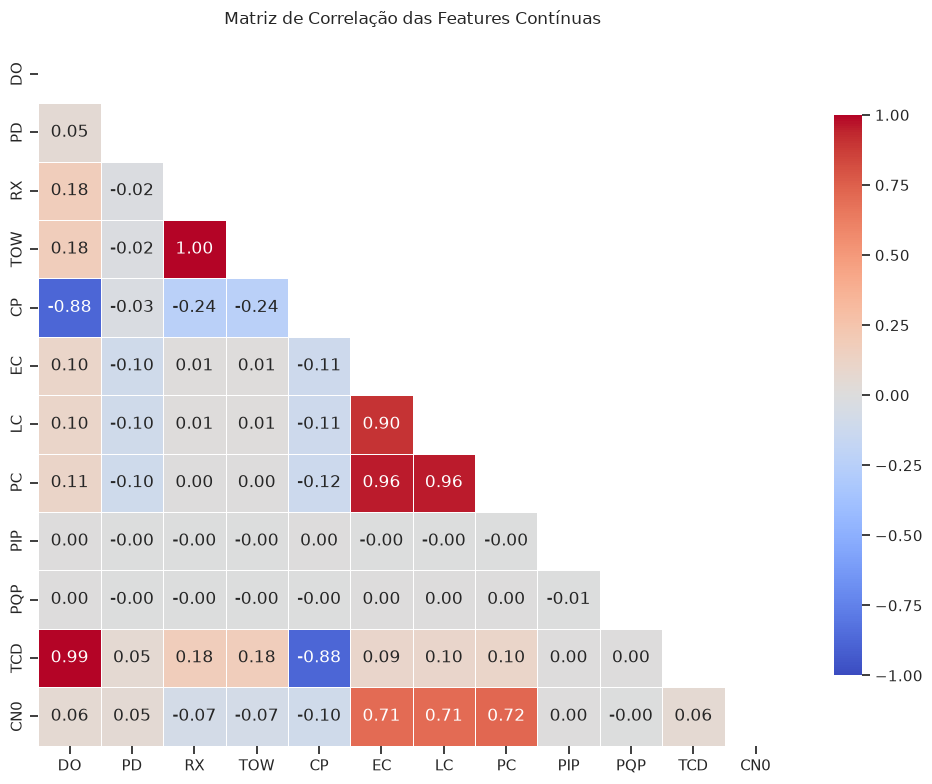

In [ ]:
# Seleção das colunas que são irrelevantes para a matriz de correlação (PRN é só uma espécie de ID, e o Output é justamente a classificação)
colunas_para_excluir = ['PRN', 'Output']
features_continuas = [c for c in df.columns if c not in colunas_para_excluir]

# Calcula a matriz de correlação usando a função nativa do pandas .corr, e especifica o método de Spearman (é o utilizado no artigo)
corr_matrix = df[features_continuas].corr(method="spearman")

# Cria a máscara para ocultar o triângulo superior e a diagonal principal (não é necessário mas eu acho mais bonito e legível de ler
# pela eliminação das redundâncias!!)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Plota a matriz otimizada (tirando as redundâncias que mencionei) usando o Seaborn (biblioteca que facilita a plotagem de gráficos do matplotlib)
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    center=0,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)

plt.title("Matriz de Correlação das Features Contínuas", pad=15)
plt.tight_layout()
plt.show()

- Pela análise da matriz de correlação de Spearman, podemos concluir que manter tanto TOW quanto RX é redundante para o treinamento devido a sua correlação perfeita, e portanto, vamos remover do dataframe final a variável de menos significância entre as duas. Nesse caso, me apoiarei na descoberta do artigo de que RX é o com menos ganho de informação, e o removerei da tabela. De forma análoga, TCD e DO possuem correlação de 0.99, e novamente me apoiando no artigo, removerei TCD do dataframe final.
- No meu último teste, também optei por eliminar dois dos correlatores e manter apenas um devido à sua alta correlação, mas, seguindo os moldes do artigo, não farei isso nesse teste.

In [ ]:
# Remoção das variáveis redundantes:
df_final = df.drop(columns=["TCD", "RX"])
# Como disse, me baseei no arquivo para eliminar as variáveis menos significativas de cada par de redundância.

- Além disso, para o treinamento em si, vamos remover as colunas PRN e Output, uma vez que o modelo não pode saber a classe real e o PRN é um ID irrelevante para análise dos dados.

In [ ]:
# Remoção das colunas desnecessárias (como disse no markdown acima):
X = df_final.drop(columns=["PRN", "Output"])

# Separação dos alvos (multiclass e binario):
y_multi = df["Output"]
y_bin = df["Output"].apply(lambda x: 0 if x == 0 else 1)
# A função lambda do numpy transforma cada número de output em 1 caso seja um dos ataques (1, 2, 3 ou 4) e mantém o 0 somente caso já fosse 0.
# Isso transforma uma coluna de output multiclasse em uma coluna binária para os modelos!!

---
- Análise da distribuição das classes: (gráficos de barras)

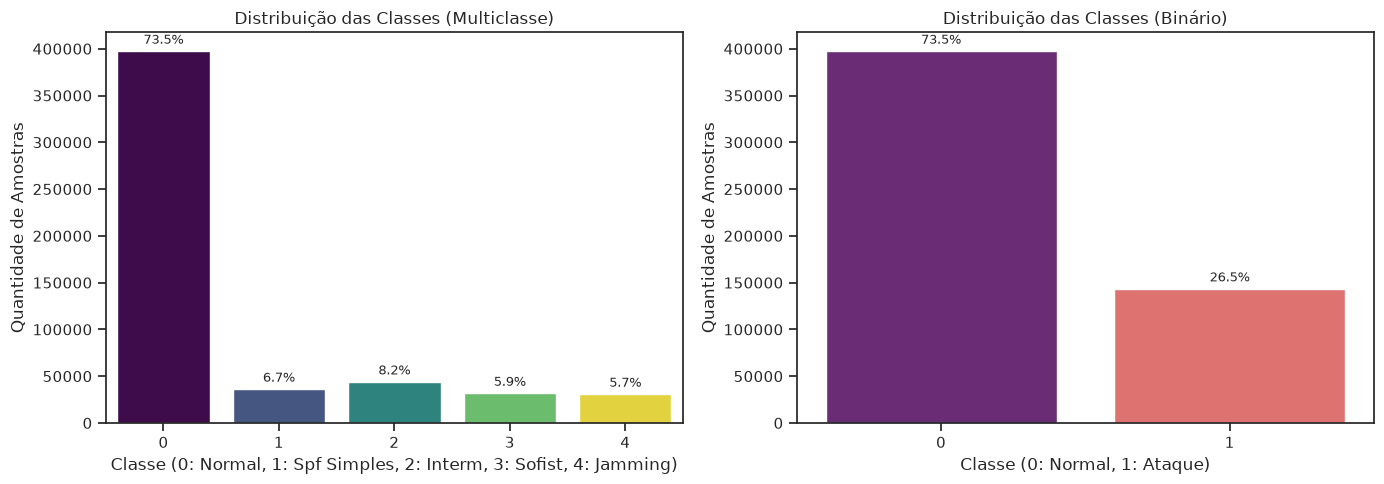

In [ ]:
# Nessa célula vamos gerar a distribuição de classes em gráfico de barras, assim como o presente no artigo.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# O comprimento do dataframe é igual ao número de amostras (n de linhas) (isso é necessário para outras coisas nessa célula)
total_amostras = len(df)

# Plota as barras da distribuição de classes em multiclasse usando o seaborn.
ax1 = sns.countplot(
    x=y_multi,
    hue=y_multi,
    ax=axes[0],
    palette="viridis",
    legend=False,
)
# Customização dos títulos e da legenda do gráfico para legibilidade melhorada :)
axes[0].set_title("Distribuição das Classes (Multiclasse)")
axes[0].set_xlabel(
    "Classe (0: Normal, 1: Spf Simples, 2: Interm, 3: Sofist, 4: Jamming)"
)
axes[0].set_ylabel("Quantidade de Amostras")

# Adiciona os números em porcentagens (o dataset é bem desbalanceado porque tem muito mais amostras controle/sem ataque do que com ataques)
for p in ax1.patches:
    height = p.get_height()
    percentage = f"{(height / total_amostras) * 100:.1f}%"
    ax1.annotate(
        percentage,
        (p.get_x() + p.get_width() / 2.0, height),
        ha="center",
        va="bottom",
        fontsize=9,
        xytext=(0, 3),
        textcoords="offset points",
    )
# fim da plotagem multiclasse

# Plota as barras da distribuição de classes usando classe binária no seaborn.
ax2 = sns.countplot(
    x=y_bin, hue=y_bin, ax=axes[1], palette="magma", legend=False
)
# Customização da legenda e títulos novamente
axes[1].set_title("Distribuição das Classes (Binário)")
axes[1].set_xlabel("Classe (0: Normal, 1: Ataque)")
axes[1].set_ylabel("Quantidade de Amostras")

# Adiciona novamente a porcentagem do total para legibilidade e comparação
for p in ax2.patches:
    height = p.get_height()
    percentage = f"{(height / total_amostras) * 100:.1f}%"
    ax2.annotate(
        percentage,
        (p.get_x() + p.get_width() / 2.0, height),
        ha="center",
        va="bottom",
        fontsize=9,
        xytext=(0, 3),
        textcoords="offset points",
    )

plt.tight_layout()
plt.show()

- Podemos ver que há uma forte concentração da classe 0, assim como no último dataset que eu analisei. Entretanto, é um pouco menor nesse dataset, e agora também existe a classe de jamming.

---

## **4. Explicação dos classificadores base**
Nesta seção, eu quis adicionar uma breve explicação de cada modelo de machine learning que vai ser utilizado no teste, explicando como eles funcionam e a relação com o dataset.

---

### 4.1. Gaussian Naive Bayes (GNB)
* **Como funciona:** Aplica o Teorema de Bayes (uma fórmula estatística que almeja prever a probabilidade de um evento acontecer com base em prévios), assumindo independência absoluta entre as *features* e uma distribuição gaussiana (como uma curva de sino, em que os dados se concentram principalmente em torno da média) para os dados.
* **Adequação ao dataset:** É computacionalmente muito rápido, mas sofre ao lidar com este dataset devido à forte interdependência e correlações complexas entre as características de sinal de GPS, levando a uma acurácia muito baixa. Essencialmente, esse modelo é uma baseline puramente estatística.

### 4.2. K-Nearest Neighbors (KNN)
* **Como funciona:** Classifica uma nova amostra por votação majoritária com base na distância (ex: Manhattan/Euclidiana) aos $k$ vizinhos mais próximos no espaço de atributos.
* **Adequação ao dataset:** Funciona bem para capturar fronteiras locais de decisão, mas perde desempenho no cenário multiclasse devido à diluição de votos e ao alto custo computacional em bases de dados grandes.

### 4.3. Decision Tree (DT)
* **Como funciona:** Constrói uma estrutura em árvore dividindo recursivamente os dados com base em limiares de atributos que maximizam o Ganho de Informação (Entropia).
* **Adequação ao dataset:** **Muito bem adaptado.** Por trabalhar com regras de decisão de corte (se $X > y$), consegue isolar perfeitamente os ataques de Jamming através do atributo de ruído $C/N0$ e classificar eficazmente os padrões de Spoofing.

### 4.4. Multilayer Perceptron (MLP / NN)
* **Como funciona:** Rede neural artificial com camadas ocultas de neurônios que aprende fronteiras de decisão não-lineares complexas por meio do algoritmo de *backpropagation*.
* **Adequação ao dataset:** Possui alto poder de generalização para capturar sutilezas nos sinais de Spoofing, atingindo elevada acurácia quando os dados estão devidamente padronizados com `StandardScaler`.

### 4.5. Análise Discriminante Linear (LDA)
* **Como funciona:** Projeta os dados em um espaço de menor dimensão que maximiza a separação entre as médias das classes e minimiza a variação interna de cada classe.
* **Adequação ao dataset:** Desempenho limitado, pois assume que as classes possuem distribuições gaussianas com a mesma matriz de covariância, premissa que não se sustenta no comportamento dinâmico de ataques a drones.

### 4.6. Regressão Logística (LR)
* **Como funciona:** Modela a probabilidade de pertencer a uma classe aplicando a função logística sigmoide a uma combinação linear das características.
* **Adequação ao dataset:** Apresenta baixo desempenho geral por tentar criar separadores lineares em um problema onde as fronteiras entre os ataques de Spoofing são fortemente não-lineares.

---

### 4.7. AdaBoost (AB)
* **Como funciona:** Algoritmo de *Boosting* que treina sequencialmente classificadores fracos (geralmente árvores rasas), ajustando os pesos das amostras a cada iteração para focar nos erros do modelo anterior.
* **Adequação ao dataset:** Funciona excelente no cenário binário (Ataque vs. Normal), mas apresenta queda drástica no cenário multiclasse por ter dificuldade em reponderar amostras ao lidar com muitas classes simultâneas.

### 4.8. Random Forest (RF)
* **Como funciona:** Algoritmo de *Bagging* que cria uma floresta de múltiplas Árvores de Decisão independentes treinadas em subconjuntos aleatórios de dados e atributos, decidindo por votação majoritária.
* **Adequação ao dataset:** **Altamente adequado.** Reduz significativamente o risco de *overfitting* da Árvore de Decisão simples e alcança excelente acurácia ao combinar múltiplos estimadores para separar os diferentes níveis de Spoofing.

### 4.9. Gradient Boosting (GB)
* **Como funciona:** Constrói árvores de decisão de forma sequencial (como o AdaBoost), mas otimiza uma função de perda arbitrária utilizando o cálculo do Gradiente Descendente para corrigir os resíduos da etapa anterior.
* **Adequação ao dataset:** **Um dos melhores modelos individuais.** Demonstra excelente capacidade preditiva tanto na classificação binária quanto na multiclasse, servindo como base ideal para meta-classificadores de *Stacking*.

---

## **5. Treinamento e teste dos modelos**
Feita a explicação, agora vamos de fato à divisão dos dados entre treino e teste e o treinamento dos modelos. Usaremos uma divisão de 75% de dados para treino e 25% para teste, e também temos que fazer o escalamento das variáveis devido à natureza de alguns dos modelos envolvidos, em que a escala discrepante das features pode fazer muita diferença nas tomadas de decisões.

### **5.1. Multiclasse**

In [9]:
# Importação dos modelos e bibliotecas do sklearn necessárias;
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier

# Divisão Treino/Teste (Multiclasse)
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X, y_multi, test_size=0.25, random_state=42, stratify=y_multi
)

# Escalamento para o conjunto Multiclasse
scaler = StandardScaler()
X_train_m_scaled = scaler.fit_transform(X_train_m)
X_test_m_scaled = scaler.transform(X_test_m)

# Dicionário com os 9 modelos
modelos = {
    "GNB": GaussianNB(var_smoothing=410103958.85331386),
    "KNN": KNeighborsClassifier(n_neighbors=85, p=1),
    "DT": DecisionTreeClassifier(criterion="entropy", max_depth=19, random_state=42),
    "NN": MLPClassifier(activation="tanh", max_iter=2000, random_state=42),
    "LDA": LinearDiscriminantAnalysis(solver="svd"),
    "LR": LogisticRegression(solver="lbfgs", max_iter=500, random_state=42), # OBS: no artigo, é recomendado o liblinear, mas ele não é aplicável pra multiclasse.
    "AB": AdaBoostClassifier(n_estimators=1000, random_state=42),
    "RF": RandomForestClassifier(criterion="entropy", random_state=42),
    "GB": GradientBoostingClassifier(learning_rate = 0.1, random_state=42)
}

# Execução do Treino Multiclasse
resultados_multi = {}
predicoes_multi = {}

for nome, modelo in modelos.items():
    # Modelos sensíveis à escala usam os dados padronizados
    if nome in ["KNN", "NN", "LDA", "LR"]:
        modelo.fit(X_train_m_scaled, y_train_m)
        preds = modelo.predict(X_test_m_scaled)
    else:
        modelo.fit(X_train_m, y_train_m)
        preds = modelo.predict(X_test_m)
    
    acc = accuracy_score(y_test_m, preds) * 100
    resultados_multi[nome] = acc
    predicoes_multi[nome] = preds
    print(f"Modelo {nome} concluído. Acurácia: {acc:.2f}%")

Modelo GNB concluído. Acurácia: 73.46%
Modelo KNN concluído. Acurácia: 86.38%
Modelo DT concluído. Acurácia: 94.24%
Modelo NN concluído. Acurácia: 92.94%
Modelo LDA concluído. Acurácia: 79.20%
Modelo LR concluído. Acurácia: 79.17%
Modelo AB concluído. Acurácia: 78.40%
Modelo RF concluído. Acurácia: 90.91%
Modelo GB concluído. Acurácia: 93.88%


### **5.2. Binário**

In [10]:
# Divisão Treino/Teste (Binário)
X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(
    X, y_bin, test_size=0.25, random_state=42, stratify=y_bin
)

# Escalamento para o conjunto binário
scaler_b = StandardScaler()
X_train_b_scaled = scaler_b.fit_transform(X_train_b)
X_test_b_scaled = scaler_b.transform(X_test_b)

# Dicionário com os 9 modelos re-instanciados
modelos_binario = {
    "GNB": GaussianNB(var_smoothing=410103958.85331386),
    "KNN": KNeighborsClassifier(n_neighbors=85, p=1),
    "DT": DecisionTreeClassifier(
        criterion="entropy", max_depth=19, random_state=42
    ),
    "NN": MLPClassifier(activation="tanh", max_iter=500, random_state=42),
    "LDA": LinearDiscriminantAnalysis(solver="svd"),
    "LR": LogisticRegression(solver="liblinear", max_iter=500, random_state=42),
    "AB": AdaBoostClassifier(n_estimators=1000, random_state=42),
    "RF": RandomForestClassifier(criterion="entropy", random_state=42),
    "GB": GradientBoostingClassifier(learning_rate=0.1, random_state=42),
}

# Execução do Treino Binário
resultados_binario = {}
predicoes_binario = {}

for nome, modelo in modelos_binario.items():
    # Modelos sensíveis à escala usam os dados padronizados
    if nome in ["KNN", "NN", "LDA", "LR"]:
        modelo.fit(X_train_b_scaled, y_train_b)
        preds = modelo.predict(X_test_b_scaled)
    else:
        modelo.fit(X_train_b, y_train_b)
        preds = modelo.predict(X_test_b)

    acc = accuracy_score(y_test_b, preds) * 100
    resultados_binario[nome] = acc
    predicoes_binario[nome] = preds
    print(f"Binário - Modelo {nome} concluído. Acurácia: {acc:.2f}%")

Binário - Modelo GNB concluído. Acurácia: 73.46%
Binário - Modelo KNN concluído. Acurácia: 88.38%
Binário - Modelo DT concluído. Acurácia: 95.14%
Binário - Modelo NN concluído. Acurácia: 93.49%
Binário - Modelo LDA concluído. Acurácia: 78.91%
Binário - Modelo LR concluído. Acurácia: 78.76%
Binário - Modelo AB concluído. Acurácia: 89.05%
Binário - Modelo RF concluído. Acurácia: 92.46%
Binário - Modelo GB concluído. Acurácia: 92.23%



--- 

## **6. Resultados e análises**
Feito o treinamento e os testes, vamos analisar e comparar os resultados:



### 6.1. Tabela Comparativa:

In [11]:
# Unificação dos Dicionários de Resultados
df_comparativo = pd.DataFrame(
    {
        "Classificador": list(resultados_multi.keys()),
        "Multiclasse (%)": list(resultados_multi.values()),
        "Binário (%)": list(resultados_binario.values()),
    }
)

# Arredondamento para 2 casas decimais
df_comparativo["Multiclasse (%)"] = df_comparativo["Multiclasse (%)"].round(2)
df_comparativo["Binário (%)"] = df_comparativo["Binário (%)"].round(2)

# Ordenar pelos melhores resultados no Multiclasse
df_comparativo = df_comparativo.sort_values(
    by="Multiclasse (%)", ascending=False
).reset_index(drop=True)

# Exibir a Tabela Final
print("=== RESULTADOS COMPARATIVOS DOS MODELOS ===")
display(df_comparativo)

=== RESULTADOS COMPARATIVOS DOS MODELOS ===


,Classificador,Multiclasse (%),Binário (%)
0,DT,94.24,95.14
1,GB,93.88,92.23
2,NN,92.94,93.49
3,RF,90.91,92.46
4,KNN,86.38,88.38
5,LDA,79.20,78.91
6,LR,79.17,78.76
7,AB,78.40,89.05
8,GNB,73.46,73.46


Nossos modelos ganhadores em acurácia foram o DT, GB e NN. Vamos analisar a matriz de confusão de cada um para entender melhor.

---

### 6.2. Matriz de Confusão

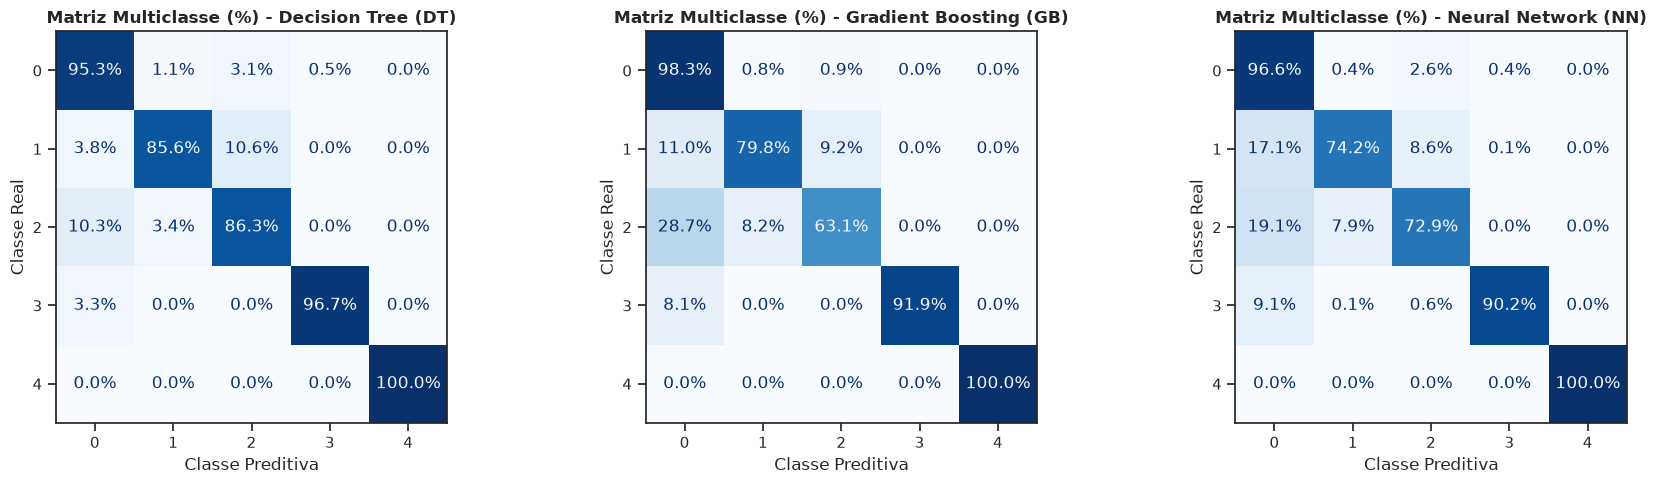

In [12]:
# ============================================ #
# MATRIZ DE CONFUSÃO MULTICLASSE (PORCENTAGEM) #
# ============================================ #
from sklearn.metrics import ConfusionMatrixDisplay

melhores_multiclasse = {
    "Decision Tree (DT)": modelos["DT"],
    "Gradient Boosting (GB)": modelos["GB"],
    "Neural Network (NN)": modelos["NN"],
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (nome, modelo) in zip(axes, melhores_multiclasse.items()):
    if nome == "Neural Network (NN)":
        y_pred = modelo.predict(X_test_m_scaled)
    else:
        y_pred = modelo.predict(X_test_m)

    ConfusionMatrixDisplay.from_predictions(
        y_test_m,
        y_pred,
        ax=ax,
        cmap="Blues",
        colorbar=False,
        normalize="true",
        values_format=".1%",
    )
    ax.set_title(
        f"Matriz Multiclasse (%) - {nome}", fontsize=12, fontweight="bold"
    )
    ax.set_xlabel("Classe Preditiva")
    ax.set_ylabel("Classe Real")

plt.tight_layout()
plt.show()

Podemos ver que, nos testes multiclasse, os modelos líderes conseguiram cravar 100% de acurácia na detecção de jamming. Isso comprova que esse ataque, ao menos nessas simulações, é simples de encontrar. No DT e no GB, vemos que a classe 1 e 2 se confundiram com muita frequência, mostrando que elas possuem características de tráfego muito similares.

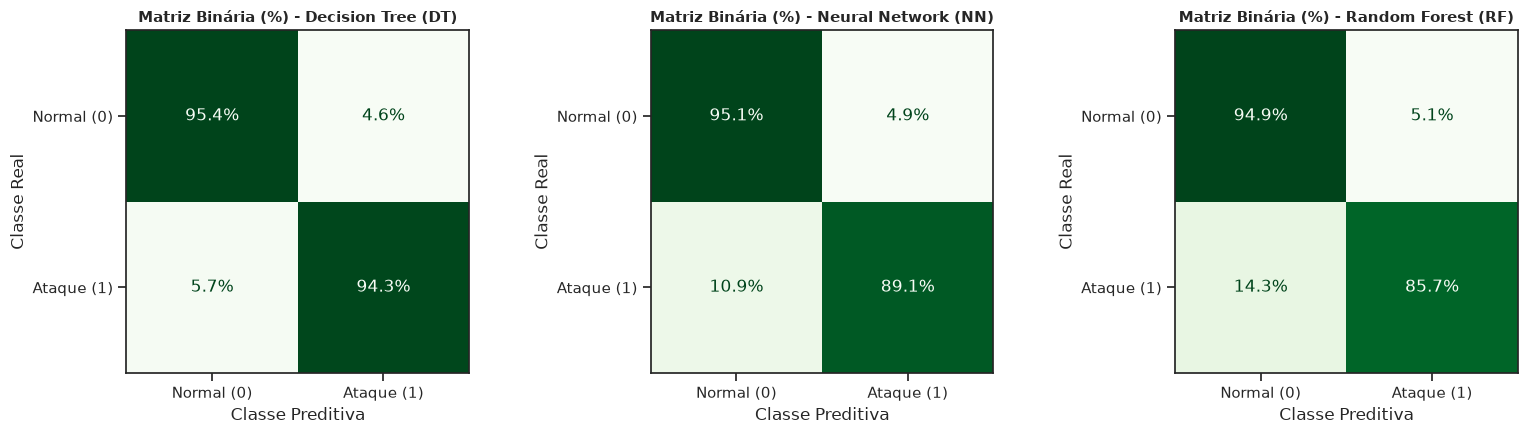

In [13]:
# ========================================== #
# MATRIZ DE CONFUSÃO BINÁRIA (PORCENTAGEM)   #
# ========================================== #
melhores_binario = {
    "Decision Tree (DT)": modelos_binario["DT"],
    "Neural Network (NN)": modelos_binario["NN"],
    "Random Forest (RF)": modelos_binario["RF"],
}

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

for ax, (nome, modelo) in zip(axes, melhores_binario.items()):
    if nome in ["Neural Network (NN)", "NN"]:
        y_pred_b = modelo.predict(X_test_b_scaled)
    else:
        y_pred_b = modelo.predict(X_test_b)

    ConfusionMatrixDisplay.from_predictions(
        y_test_b,
        y_pred_b,
        ax=ax,
        cmap="Greens",
        colorbar=False,
        normalize="true",  # Normaliza pelas linhas (Classe Real)
        values_format=".1%",  # Formata como porcentagem (ex: 98.4%)
        display_labels=["Normal (0)", "Ataque (1)"],
    )
    ax.set_title(
        f"Matriz Binária (%) - {nome}", fontsize=11, fontweight="bold"
    )
    ax.set_xlabel("Classe Preditiva")
    ax.set_ylabel("Classe Real")

plt.tight_layout()
plt.show()

Assim como no artigo, tomamos aqui prioridade na análise da taxa de **falsos negativos**, que é objetivamente o pior erro em sistemas críticos de segurança. A DT teve a menor taxa de falsos negativos, de apenas 5,7%, enquanto também sendo entre as 3 melhores a com a menor taxa de falsos positivos, apesar de todos os modelos terem ido bem nesse quesito, próximos uns dos outros.


---

### 6.3. Análise de importância das features

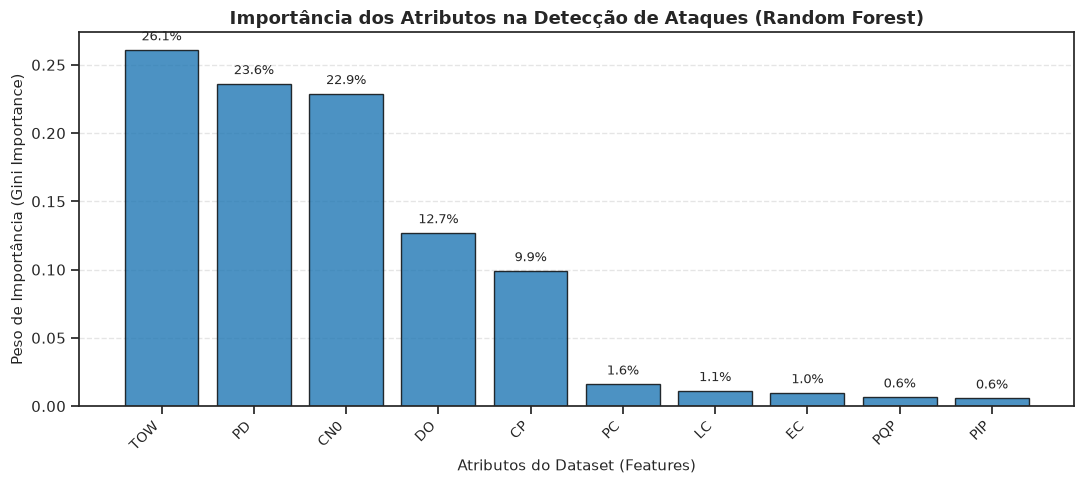

In [14]:
# Usando o modelo Random Forest (padrão científico para importância)
modelo_feat = modelos["RF"]

importancias = modelo_feat.feature_importances_
indices = np.argsort(importancias)[::-1]
colunas_ordenadas = [X.columns[i] for i in indices]

# Plota o gráfico de barras
plt.figure(figsize=(11, 5))
plt.title(
    "Importância dos Atributos na Detecção de Ataques (Random Forest)",
    fontsize=13,
    fontweight="bold",
)
bars = plt.bar(
    range(X.shape[1]),
    importancias[indices],
    color="#1f77b4",
    edgecolor="black",
    alpha=0.8,
)

# rótulos no eixo X
plt.xticks(
    range(X.shape[1]), colunas_ordenadas, rotation=45, ha="right", fontsize=10
)
plt.ylabel("Peso de Importância (Gini Importance)", fontsize=11)
plt.xlabel("Atributos do Dataset (Features)", fontsize=11)
plt.grid(axis="y", linestyle="--", alpha=0.5)

# valores percentuais em cima de cada barra
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2.0,
        height + 0.005,
        f"{height:.1%}",
        ha="center",
        va="bottom",
        fontsize=9,
    )

plt.tight_layout()
plt.show()

Com base no gráfico, vemos que TOW, PD e CN0 foram em média as features mais ponderadas na tomada de decisões. 
- O TOW lidera pela percepção do Machine Learning que saltos incoerentes nele são uma assinatura clara de adulteração na navegação; Quando ocorrem ataques de spoofing, o atacante injeta sinais que causam deslocamento ou descontinuidade no relógio/tempo transmitido.
- O Pseudorange foi crucial também porque, para conseguir alterar a posição calculada do drone para desviá-lo da rota, o gerador de spoofing obrigatoriamente precisa forjar valores falsos de PD.
- O CN0 também é muito importante, principalmente para detecção de jamming, porque ele destrói a relação sinal-ruído, geralmente fazendo ela cair drasticamente. Porém, no spoofing sofisticado, o CN0 do sinal falso é muito próximo do nível normal, o que diminui seu poder de discriminação isolado.


---

### 6.4. Classification report
Como os dados não são muito uniformes entre as classes, usar a acurácia isolada é um parâmetro impreciso. Então, vamos usar o classification report do scikit-learn para nos dar outros parâmetros importantes, como o F1-Score.

In [15]:
import warnings
warnings.filterwarnings("ignore")

from sklearn.metrics import classification_report

print("=== RELATÓRIOS DETALHADOS (MULTICLASSE) ===")
for nome, y_pred in predicoes_multi.items():
    print(f"\n--- Classificador: {nome} (Multiclasse) ---")
    print(classification_report(y_test_m, y_pred, digits=4))
    print("-" * 55)

print("\n=== RELATÓRIOS DETALHADOS (BINÁRIO) ===")
for nome, y_pred in predicoes_binario.items():
    print(f"\n--- Classificador: {nome} (Binário) ---")
    print(classification_report(y_test_b, y_pred, digits=4, zero_division=0))
    print("-" * 55)

=== RELATÓRIOS DETALHADOS (MULTICLASSE) ===

--- Classificador: GNB (Multiclasse) ---
              precision    recall  f1-score   support

           0     0.7346    1.0000    0.8470     99412
           1     0.0000    0.0000    0.0000      9110
           2     0.0000    0.0000    0.0000     11053
           3     0.0000    0.0000    0.0000      7999
           4     0.0000    0.0000    0.0000      7755

    accuracy                         0.7346    135329
   macro avg     0.1469    0.2000    0.1694    135329
weighted avg     0.5396    0.7346    0.6222    135329

-------------------------------------------------------

--- Classificador: KNN (Multiclasse) ---
              precision    recall  f1-score   support

           0     0.8652    0.9859    0.9216     99412
           1     0.7575    0.4923    0.5968      9110
           2     0.7249    0.3459    0.4683     11053
           3     0.9131    0.3534    0.5096      7999
           4     0.9996    1.0000    0.9998      7755

 

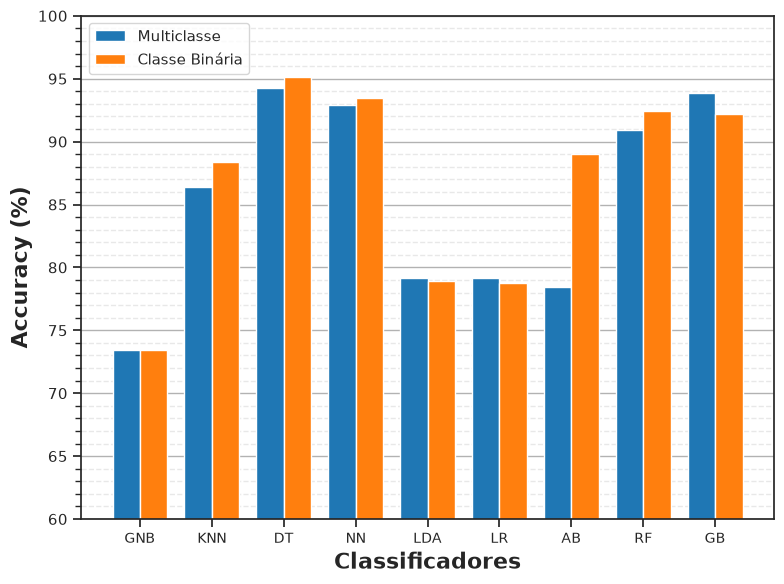

In [16]:
# Extrai só os números do dicionário
valores_multi = list(resultados_multi.values())
valores_binario = list(resultados_binario.values())

# Definição das posições e largura das barras
x = np.arange(len(modelos))
largura = 0.38  # Largura de cada barra

# Criar a figura
fig, ax = plt.subplots(figsize=(8, 6))

# Criar as barras agrupadas
barras_multi = ax.bar(
    x - largura / 2,
    valores_multi,
    largura,
    label="Multiclasse",
    color="#1f77b4",
)
barras_binaria = ax.bar(
    x + largura / 2, valores_binario, largura, label="Classe Binária", color="#ff7f0e"
)

# Personalização do gráfico (Eixos, Títulos e Escala)
ax.set_ylabel("Accuracy (%)", fontsize=16, fontweight="bold")
ax.set_xlabel("Classificadores", fontsize=16, fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels(modelos, fontsize=10)
ax.set_ylim(60, 100)  # Limite do eixo Y de 60 a 100

# Legenda no canto superior esquerdo
ax.legend(loc="upper left", fontsize=11)

# Estilo das linhas de grade (Grid)
ax.set_axisbelow(True)
ax.yaxis.grid(True, which="major", linestyle="-", color="gray", alpha=0.6)
ax.yaxis.grid(
    True, which="minor", linestyle="--", color="lightgray", alpha=0.5
)
ax.minorticks_on()
ax.tick_params(axis="x", which="minor", bottom=False)  # Remove minor ticks no X

# Ajustar layout para não cortar texto e exibir
plt.tight_layout()
plt.show()

### 6.3. Bônus - Stacking

In [17]:
from sklearn.ensemble import StackingClassifier, GradientBoostingClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report

# O KNN e a NN para incluem o Scaler via Pipeline automático
modelos_base_stacking = [
    ('KNN', make_pipeline(StandardScaler(), modelos['KNN'])),
    ('DT',  modelos['DT']),
    ('NN',  make_pipeline(StandardScaler(), modelos['NN'])),
    ('RF',  modelos['RF'])
]

# Meta-Modelo escolhido: Gradient Boosting
meta_modelo = GradientBoostingClassifier(learning_rate=0.1, random_state=42)

# 3. Inicialização do Stacking
stacking_model = StackingClassifier(
    estimators=modelos_base_stacking,
    final_estimator=meta_modelo,
    cv=5,
    n_jobs=-1
)

# Treinamento
# Passamos os dados NÃO escalados (X_train_m), pois os Pipelines cuidam de escalar KNN e NN internamente!
print("Treinando o Stacking Classifier com os top modelos (isso pode levar alguns segundos)...")
stacking_model.fit(X_train_m, y_train_m)

# Predição no conjunto de teste original
y_pred_stack = stacking_model.predict(X_test_m)

# Avaliação
print("\n--- Relatório de Classificação (Stacking Bônus) ---")
print(classification_report(y_test_m, y_pred_stack))

Treinando o Stacking Classifier com os top modelos (isso pode levar alguns segundos)...

--- Relatório de Classificação (Stacking Bônus) ---
              precision    recall  f1-score   support

           0       0.99      0.99      0.99     99412
           1       0.92      0.91      0.92      9110
           2       0.90      0.93      0.92     11053
           3       0.99      0.99      0.99      7999
           4       1.00      1.00      1.00      7755

    accuracy                           0.98    135329
   macro avg       0.96      0.96      0.96    135329
weighted avg       0.98      0.98      0.98    135329



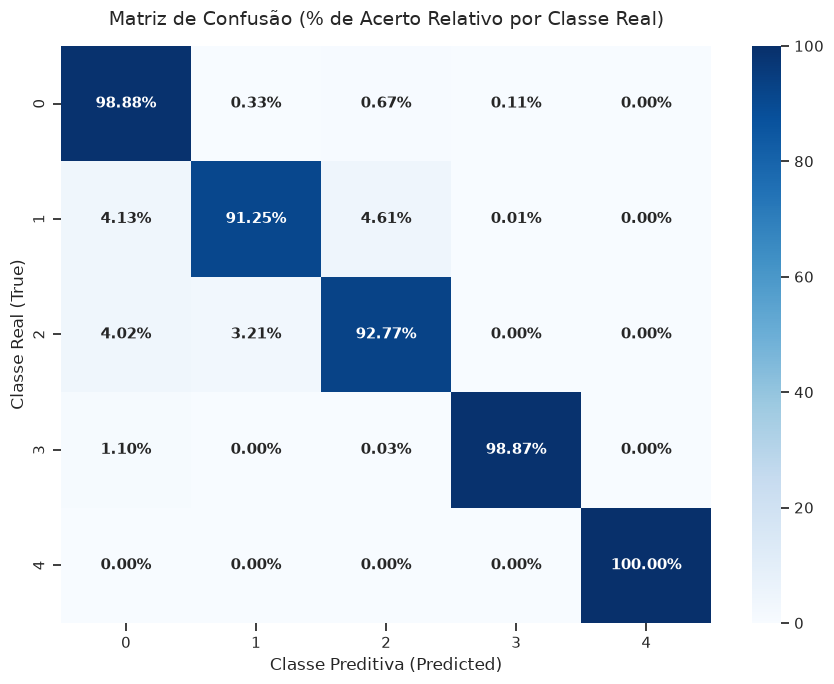

In [19]:
from sklearn.metrics import confusion_matrix

cm_relative = confusion_matrix(y_test_m, y_pred_stack, normalize='true') * 100

# Renderiza o Heatmap com Porcentagens por Classe
plt.figure(figsize=(9, 7))
sns.heatmap(
    cm_relative,
    annot=True,
    fmt='.2f',  # Formatação com duas casas decimais
    cmap='Blues',
    xticklabels=stacking_model.classes_,
    yticklabels=stacking_model.classes_,
    cbar=True,
    annot_kws={"size": 11, "weight": "bold"}
)

plt.title('Matriz de Confusão (% de Acerto Relativo por Classe Real)', fontsize=14, pad=15)
plt.xlabel('Classe Preditiva (Predicted)', fontsize=12)
plt.ylabel('Classe Real (True)', fontsize=12)

# Adiciona o símbolo de % visualmente nos números do gráfico
for text in plt.gca().texts:
    text.set_text(f"{text.get_text()}%")

plt.tight_layout()
plt.show()


---

## **7. Conclusão e considerações finais**
Analisando a classificação, a **Árvore de Decisão (DT)** superou todos os outros classificadores, alcançando as **maiores acurácias e F1-Scores ponderados** em ambas as abodargens (binária e multiclasse). Este desempenho se dá pela capacidade da DT de isolar regras condicionais rígidas necessárias para distinguir classes sobrepostas, como a classe 2. O **Gradient Boosting (GB) e as Redes Neurais (NN)** também tiveram bons resultados, enquanto modelos lineares e probabilísticos, por outro lado, mostraram-se ineficazes para o dataset (o GNB, por exemplo, preveu 100% dos dados como tráfego normal devido ao desbalanceamento de dados). 
### 7.1. Comparação com o Artigo de Referência (Lemos & Silva, 2024)

Para validar nosso projeto, comparamos os resultados obtidos com o artigo de referência na mesma base de dados:

* **Resultado do Artigo:** Alcançou **98,08%** de acurácia no multiclasse usando **Stacking** (um ensemble complexo juntando KNN, DT, NN, RF e GB).
* **Nosso Resultado:** Nosso melhor modelo individual foi a **Árvore de Decisão (DT)** com **94,24%** (multiclasse) e **95,14%** (binário).
* **Takeaway do Projeto:** O Stacking do artigo ganha por ~4% de acurácia, mas exige um custo computacional muito maior. Para rodar direto no hardware limitado de um drone em tempo real, a nossa **Decision Tree** se mostra uma alternativa mais leve e consideravelmente mais rápida. Mas, no geral, comparando com os resultados dos modelos individuais do artigo, temos resultados muito semelhantes.

OBS: O stacking rodado no final atingiu uma acurácia enorme, mas demorou muito tempo para ser rodado (cerca de 3x mais que o multiclasse padrão). Então, por mais que sua precisão, acurácia e métricas no geral sejam incríveis e de longe as melhores, acabou sendo impraticável para uso on-the-fly.